# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

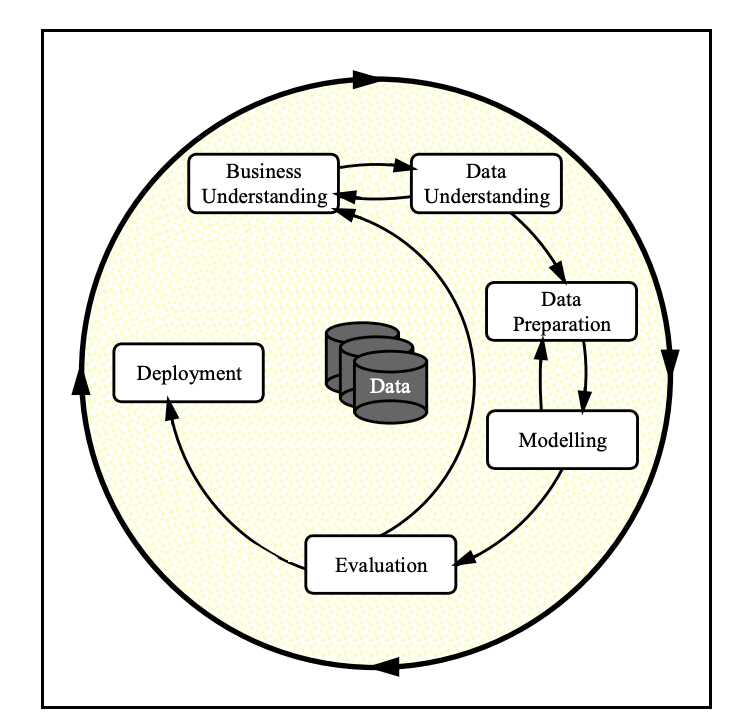

To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

▶ **Answer:** What dependent variables and features have the most significant impact on the on the predicted target dependent variable "car price". The goal is to estimate the coefficients $\beta_{i}$ for each feature, which quantify the specific impact and statistical significance of each variable on the overall price.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

▶ **Answer**
*   Explore variables set
*   Identify numerical, categorical, and Ordinal variables
*   Explore distribution of the independent variables
*   Explore correlations between independent variables
*   Explore correclateion between independent and predicted variable
*   Explore distributions of the independent variables




### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

link = 'https://drive.google.com/file/d/1wjlOCB0nRs1A4EgMm5roTNLs5gOFJbEf/view?usp=sharing'
id = link.split("/")[-2] #get file id to read in

downloaded = drive.CreateFile({'id':id})
downloaded.GetContentFile('vehicles.csv')

data = pd.read_csv('vehicles.csv')

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

          column  na_count  na_percent
11          size    306361    0.717675
4      cylinders    177678    0.416225
3      condition    174104    0.407852
9            VIN    161042    0.377254
10         drive    130567    0.305863
13   paint_color    130203    0.305011
12          type     92858    0.217527
1   manufacturer     17646    0.041337
7   title_status      8242    0.019308
2          model      5277    0.012362
6       odometer      4400    0.010307
5           fuel      3013    0.007058
8   transmission      2556    0.005988
0           year      1205    0.002823


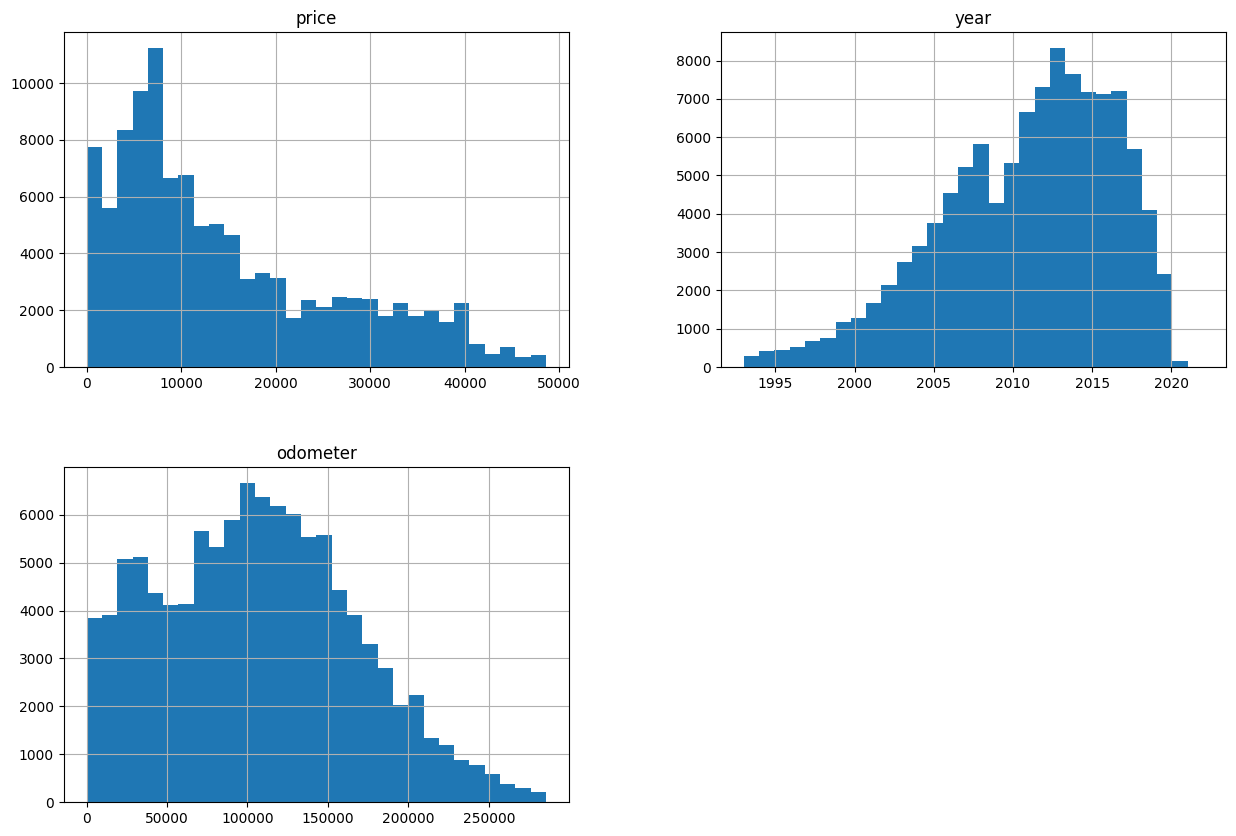


region , number of categories:  403
region
vermont                1344
columbus               1305
jacksonville           1183
albany                 1032
boston                 1002
                       ... 
west virginia (old)       4
southwest MS              2
fort smith, AR            2
logan                     2
southwest TX              1
Name: count, Length: 403, dtype: int64

manufacturer , number of categories:  40
manufacturer
ford               18695
chevrolet          15866
toyota              9610
honda               6537
nissan              6097
jeep                5447
gmc                 4435
dodge               4003
ram                 3858
bmw                 3137
subaru              2706
hyundai             2597
mercedes-benz       2596
lexus               2164
volkswagen          2139
kia                 2035
chrysler            1929
cadillac            1522
infiniti            1464
buick               1434
mazda               1300
audi                1270
acur

In [31]:
data.head()
data['year'] = data['year'].astype(pd.Int64Dtype())

# Removing missing values
data.shape # (426880, 18)
na_list = [[col,data[col].isna().sum()] for col in data.columns if data[col].isna().sum() > 0]
na_df = pd.DataFrame(na_list, columns=['column','na_count'])
na_df = na_df.sort_values(by='na_count', ascending=False)
na_df['na_percent'] = na_df['na_count'] / data.shape[0]
print(na_df)
# size (72%), cylinders(41%), and condition (40%) all show very high % of missing values
# while all these variables might be important predictors of price,
# to maintian most of the data I will not use size
# as cylinders and type are likely good indicator of the size
data_clean = data.drop(columns=['id', 'size', 'VIN'])
data_clean = data_clean.dropna()
data_clean.shape  # (115988, 15)

# ------------------------------------------------------------------------------
# Removing outliers

# Select only numeric columns for outlier detection
numeric_cols = data_clean.select_dtypes(include=np.number).columns

Q1 = data_clean[numeric_cols].quantile(0.25)
Q3 = data_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows that have an outlier in ANY numeric column
outlier_mask = ((data_clean[numeric_cols] < lower_bound) | (data_clean[numeric_cols] > upper_bound)).any(axis=1)
data_clean = data_clean[~outlier_mask]
data_clean.shape # (113004, 15)

# ------------------------------------------------------------------------------
# Plotting histograms and counts

# Numerical variables
data_clean[data_clean['price']<100000].hist(bins=30, figsize=(15, 10))
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Categorical variables
categorical_cols = data_clean.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
  col_vals = data_clean[col].value_counts()
  print()
  print(col, ', number of categories: ', len(col_vals))
  # print(col_vals)

# ------------------------------------------------------------------------------
# Replace year with age to make model applicable to current year

data_clean['age'] = 2023 - data_clean['year']
data_clean = data_clean.drop(columns=['year'])

#drop model - too many values
data_clean = data_clean.drop(columns=['model'])

# drop region, state - recommendation is nationwide
data_clean = data_clean.drop(columns=['region','state'])

# drop "other" cylinders and make it numerical value
data_clean = data_clean[data_clean['cylinders'] != 'other']
data_clean['cylinders'] = data_clean['cylinders'].str.replace(' cylinders', '')
data_clean['cylinders'] = data_clean['cylinders'].astype(int)


# ------------------------------------------------------------------------------

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [9]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import set_config

In [50]:
auto_df = pd.get_dummies(data_clean)
auto_X = auto_df.drop(['price'], axis = 1)
auto_y = data_clean['price']
auto_X_train, auto_X_test, auto_y_train, auto_y_test = train_test_split(auto_X, auto_y,
                                                                       test_size = 0.2,
                                                                       random_state = 42)

sequential_pipe = Pipeline([('selector', SequentialFeatureSelector(LinearRegression(),
                                                                   n_features_to_select=20)),
                                                                    ('linreg', LinearRegression())])
model = sequential_pipe.fit(auto_X_train, auto_y_train)


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [51]:
sequential_train_mse = mean_squared_error(auto_y_train, sequential_pipe.predict(auto_X_train))
sequential_test_mse = mean_squared_error(auto_y_test, sequential_pipe.predict(auto_X_test))

print('Train MSE: ', sequential_train_mse)
print('Test MSE: ', sequential_test_mse)

coefs = sequential_pipe.named_steps['linreg'].coef_
features = sequential_pipe.named_steps['selector'].get_feature_names_out()
model_coefs = pd.DataFrame({'Feature': features, 'Coef': coefs})
print(model_coefs)

# ------------------------------------------------------
# avaluate p-values with OLS module

import statsmodels.api as sm

X_train_selected = auto_X_train[features].astype(float)
X_train_const = sm.add_constant(X_train_selected)
sm_results = sm.OLS(auto_y_train, X_train_const).fit()

print(sm_results.summary())

Train MSE:  49641473.52370059
Test MSE:  50291051.87343211
                   Feature         Coef
0                cylinders  1322.810507
1                 odometer    -0.051871
2                      age  -780.007224
3       manufacturer_dodge -2217.512277
4       manufacturer_honda  1638.357166
5       manufacturer_lexus  3323.881305
6      manufacturer_nissan -1698.688837
7      manufacturer_toyota  2845.874656
8           condition_good   839.588748
9              fuel_diesel  8877.303130
10      title_status_clean  1610.620610
11  transmission_automatic -1764.891693
12      transmission_other  4666.263836
13               drive_fwd -3061.798865
14                type_SUV -2811.856739
15          type_hatchback -4491.769248
16           type_mini-van -3160.944345
17              type_sedan -4558.023012
18                type_van -2145.294897
19              type_wagon -4683.722741
                            OLS Regression Results                            
Dep. Variable:        

▶ **Evaluation Conclusion**

Train and Test MSE's are close, meaning that model is not overfitting

All of the selected 20 features are statistically significant, i.e. p-value < 0.01

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

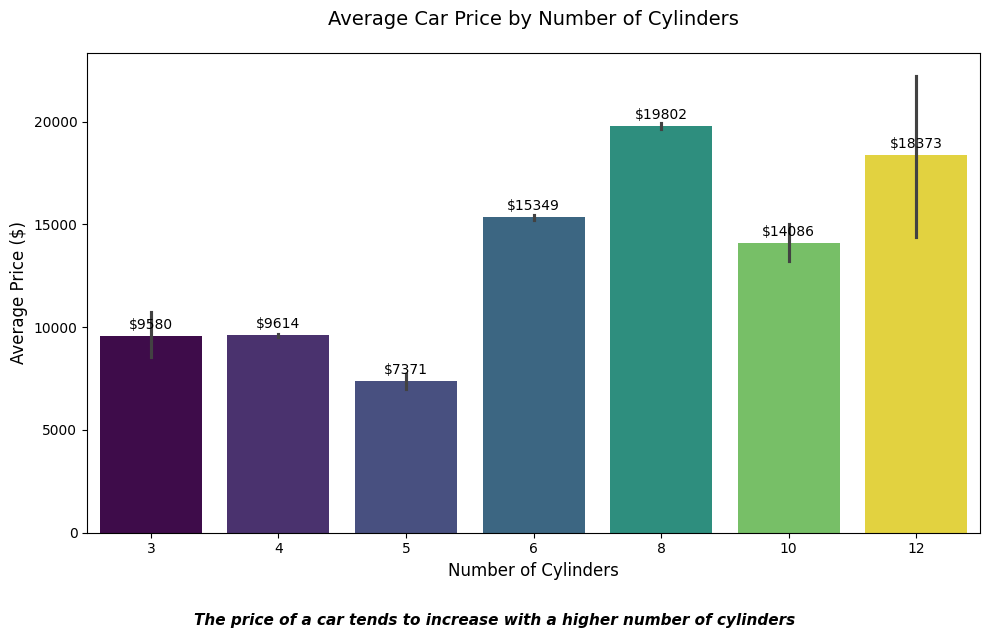

In [63]:
fig = plt.figure(figsize=(10, 6))
# 'cylindernumber' is the common column name in the UCI Automobile dataset
ax = sns.barplot(x='cylinders', y='price', data=data_clean, palette='viridis', hue='cylinders', legend=False)

# 3. Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3)

# 4. Styling and Titles
plt.title('Average Car Price by Number of Cylinders', fontsize=14, pad=20)
plt.xlabel('Number of Cylinders', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)

# 5. Add the notation below the plot
# Adjust the 'y' value (-0.15) if the text is too close or far from the axis
plt.figtext(0.5, -0.05, "The price of a car tends to increase with a higher number of cylinders",
            ha="center", fontsize=11, style='italic', fontweight='bold')

plt.tight_layout()
fig.savefig('cylinders.png')
# plt.show()

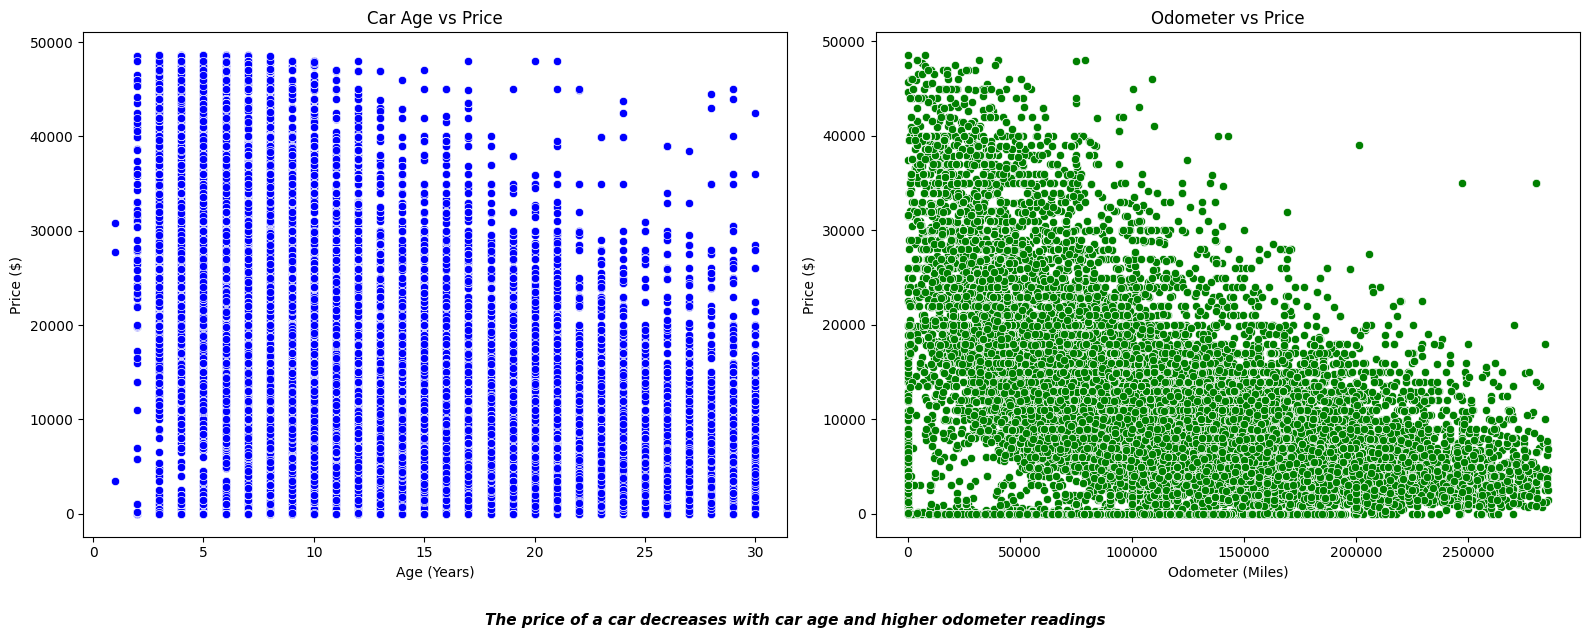

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age vs Price
sns.scatterplot(x='age', y='price', data=data_clean, ax=ax1, color='blue')
ax1.set_title('Car Age vs Price')
ax1.set_xlabel('Age (Years)')
ax1.set_ylabel('Price ($)')

# Plot 2: Odometer vs Age
# (Note: Odometer is typically on the Y-axis as the dependent variable of Age)
sns.scatterplot(x='odometer', y='price',
                data=data_clean[data_clean['manufacturer'].isin(['dodge','honda','lexus','nissan','toyota'])],
                ax=ax2, color='green')
ax2.set_title('Odometer vs Price')
ax2.set_xlabel('Odometer (Miles)')
ax2.set_ylabel('Price ($)')

plt.figtext(0.5, -0.05, "The price of a car decreases with car age and higher odometer readings",
            ha="center", fontsize=11, style='italic', fontweight='bold')

plt.tight_layout()
fig.savefig('age_and_mileage.png')

# plt.show()

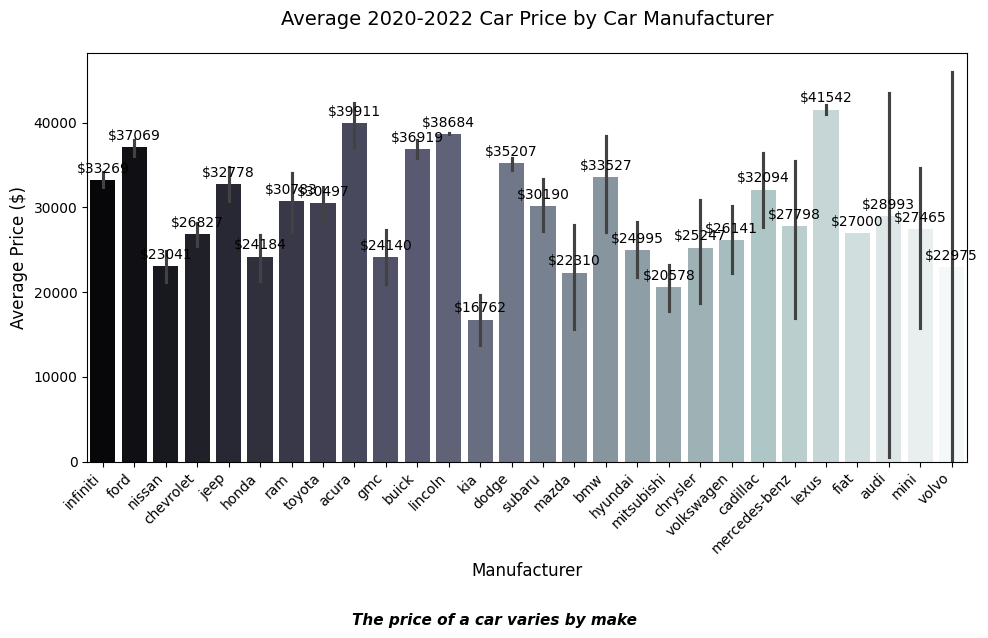

In [76]:
fig = plt.figure(figsize=(10, 6))
# 'cylindernumber' is the common column name in the UCI Automobile dataset
ax = sns.barplot(x='manufacturer', y='price', data=data_clean[data_clean['age']<=3],
                 palette='bone', hue='manufacturer', legend=False)

# 3. Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3)

# 4. Styling and Titles
plt.title('Average 2020-2022 Car Price by Car Manufacturer', fontsize=14, pad=20)
plt.xlabel('Manufacturer', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price ($)', fontsize=12)

# 5. Add the notation below the plot
# Adjust the 'y' value (-0.15) if the text is too close or far from the axis
plt.figtext(0.5, -0.05, "The price of a car varies by make",
            ha="center", fontsize=11, style='italic', fontweight='bold')

plt.tight_layout()
fig.savefig('manufacturer.png')
# plt.show()